In [2]:
import pandas as pd
import numpy as np
import pypsa
from pathlib import Path
import matplotlib.pyplot as plt

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [3]:
template = 'base_s_50__168H-T-H-B-I-A-dist1{}_2030_free{}_endo.nc'

In [4]:
sector_opts = [
    '',
    '-gas+Generator+m1.1',
    '-gas+Generator+m1.2',
    '-gas+Generator+m1.3',
    '-gas+Generator+m1.4',
    '-gas+Generator+m1.5',
    '-gas+Generator+m1.6',
    '-gas+Generator+m1.7',
    '-gas+Generator+m1.8',
    '-gas+Generator+m1.9',
    '-gas+Generator+m2.0',
]

In [5]:
tyndp_scenarios = [
    '',
    '+carbonprice-50',
    '+carbonprice-60',
    '+carbonprice-70',
    '+carbonprice-80',
    '+carbonprice-90',
    '+carbonprice-100',
    '+carbonprice-110',
    '+carbonprice-120',
]

In [6]:
idx = pd.IndexSlice

In [7]:
def get_gas_consumption(n):
    return n.statistics.energy_balance().loc[idx[:,'gas',:]].iloc[0] / 1e6

In [8]:
from itertools import product

data = pd.DataFrame(index=sector_opts, columns=tyndp_scenarios)

for sector_opt, tyndp_scenario in product(sector_opts, tyndp_scenarios):

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / template.format(sector_opt, tyndp_scenario)
    )
    data.loc[sector_opt, tyndp_scenario] = get_gas_consumption(n)

data.loc[sector_opts, tyndp_scenarios]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-50_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-60_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-70_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free+carbonprice-80_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-

,,+carbonprice-50,+carbonprice-60,+carbonprice-70,+carbonprice-80,+carbonprice-90,+carbonprice-100,+carbonprice-110,+carbonprice-120
,3318.624602,1951.545538,1747.029003,1615.732653,1364.798365,1296.365353,1219.463005,1157.297162,932.534284
-gas+Generator+m1.1,2890.856541,1710.081278,1566.109421,1338.781199,1272.748442,1198.194594,1122.147318,907.361396,846.544303
-gas+Generator+m1.2,2589.799142,1516.565437,1321.509828,1248.948937,1176.445817,949.504935,883.813803,830.831788,777.025348
-gas+Generator+m1.3,2294.178989,1306.135916,1224.141015,1156.01366,932.104632,868.289883,813.021471,763.68098,717.88434
-gas+Generator+m1.4,1959.827712,1207.185942,1144.780488,916.089843,850.56918,802.788554,754.203268,693.274914,618.604745
-gas+Generator+m1.5,1713.359148,1121.563171,900.656454,838.348107,793.695672,737.370072,668.579453,595.691762,503.28866
-gas+Generator+m1.6,1526.019721,880.962627,829.921257,781.728556,724.643442,650.663481,570.474098,472.821713,390.724307
-gas+Generator+m1.7,1307.274148,810.134627,770.771893,701.077328,622.851141,529.03924,432.35142,363.26814,326.043901
-gas+Generator+m1.8,1208.116067,762.905343,688.839843,599.107778,501.379728,413.674439,350.136856,317.265999,291.507413
-gas+Generator+m1.9,1123.672375,672.159084,584.950834,481.294694,395.159728,338.5089,312.073994,284.162841,260.181541


In [9]:
base_n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc'
)
base_gas_cost = base_n.generators.loc[base_n.generators.carrier == 'gas', 'marginal_cost'].iloc[0]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [10]:
def household_cost_burden(
    carbon_price_eur_per_tco2,
    gas_tax_eur_per_mwh,
    gas_consumption_mwh=15,
    oil_consumption_mwh=10,
    ef_gas=0.2,
    ef_oil=0.27
    ):
    """
    Annual household cost burden from a carbon tax and/or gas tax.

    Parameters
    ----------
    carbon_price_eur_per_tco2 : float – carbon tax in €/tCO₂
    gas_tax_eur_per_mwh       : float – gas-specific tax in €/MWh
    gas_consumption_mwh       : float – household gas use (default 15 MWh/yr)
    oil_consumption_mwh       : float – household oil/petrol use (default 10 MWh/yr)
    ef_gas                    : float – emission factor gas (default 0.2 tCO₂/MWh)
    ef_oil                    : float – emission factor oil (default 0.27 tCO₂/MWh)

    Returns
    -------
    dict with carbon_tax_cost, gas_tax_cost, and total_cost (all €/yr)
    """
    carbon_tax_cost = carbon_price_eur_per_tco2 * (
        gas_consumption_mwh * ef_gas + oil_consumption_mwh * ef_oil
    )
    gas_tax_cost = gas_tax_eur_per_mwh * gas_consumption_mwh
    return {
        "carbon_tax_cost": round(carbon_tax_cost, 2),
        "gas_tax_cost": round(gas_tax_cost, 2),
        "total_cost": round(carbon_tax_cost + gas_tax_cost, 2),
    }

In [11]:
consumption = data.copy()

def get_carbonprice(x):
    if x == '':
        return 0
    else:
        return int(x.split('-')[1])

def get_gas_tax(x):
    if x == '':
        return 0
    else:
        return float(x.split('+m')[1]) * base_gas_cost - base_gas_cost



consumption.columns = list(map(get_carbonprice, consumption.columns))
consumption.index = list(map(get_gas_tax, consumption.index))

consumption

,0,50,60,70,80,90,100,110,120
0.000000,3318.624602,1951.545538,1747.029003,1615.732653,1364.798365,1296.365353,1219.463005,1157.297162,932.534284
2.457832,2890.856541,1710.081278,1566.109421,1338.781199,1272.748442,1198.194594,1122.147318,907.361396,846.544303
4.915665,2589.799142,1516.565437,1321.509828,1248.948937,1176.445817,949.504935,883.813803,830.831788,777.025348
7.373497,2294.178989,1306.135916,1224.141015,1156.01366,932.104632,868.289883,813.021471,763.68098,717.88434
9.831330,1959.827712,1207.185942,1144.780488,916.089843,850.56918,802.788554,754.203268,693.274914,618.604745
12.289162,1713.359148,1121.563171,900.656454,838.348107,793.695672,737.370072,668.579453,595.691762,503.28866
14.746994,1526.019721,880.962627,829.921257,781.728556,724.643442,650.663481,570.474098,472.821713,390.724307
17.204827,1307.274148,810.134627,770.771893,701.077328,622.851141,529.03924,432.35142,363.26814,326.043901
19.662659,1208.116067,762.905343,688.839843,599.107778,501.379728,413.674439,350.136856,317.265999,291.507413
22.120491,1123.672375,672.159084,584.950834,481.294694,395.159728,338.5089,312.073994,284.162841,260.181541


In [12]:
burden = pd.DataFrame(index=consumption.index, columns=consumption.columns)

for i in range(len(consumption.index)):
    for j in range(len(consumption.columns)):
        burden.iloc[i, j] = household_cost_burden(consumption.index[i], consumption.columns[j])['total_cost']

burden

,0,50,60,70,80,90,100,110,120
0.000000,0.0,750.0,900.0,1050.0,1200.0,1350.0,1500.0,1650.0,1800.0
2.457832,14.01,764.01,914.01,1064.01,1214.01,1364.01,1514.01,1664.01,1814.01
4.915665,28.02,778.02,928.02,1078.02,1228.02,1378.02,1528.02,1678.02,1828.02
7.373497,42.03,792.03,942.03,1092.03,1242.03,1392.03,1542.03,1692.03,1842.03
9.831330,56.04,806.04,956.04,1106.04,1256.04,1406.04,1556.04,1706.04,1856.04
12.289162,70.05,820.05,970.05,1120.05,1270.05,1420.05,1570.05,1720.05,1870.05
14.746994,84.06,834.06,984.06,1134.06,1284.06,1434.06,1584.06,1734.06,1884.06
17.204827,98.07,848.07,998.07,1148.07,1298.07,1448.07,1598.07,1748.07,1898.07
19.662659,112.08,862.08,1012.08,1162.08,1312.08,1462.08,1612.08,1762.08,1912.08
22.120491,126.09,876.09,1026.09,1176.09,1326.09,1476.09,1626.09,1776.09,1926.09


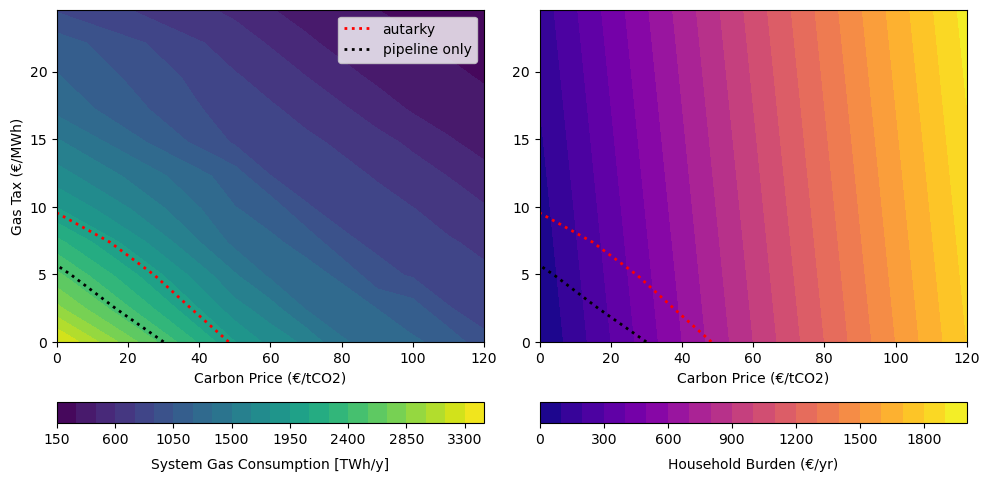

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Ensure values are float and no dtype issues
consumption_np = consumption.values.astype(float)
burden_np = burden.values.astype(float)

# Meshgrid for axes
X, Y = np.meshgrid(consumption.columns.values.astype(float), consumption.index.values.astype(float))

# Plot consumption as a contourplot in first axis
cf1 = ax[0].contourf(X, Y, consumption_np, levels=20, cmap="viridis")
cb1 = plt.colorbar(cf1, ax=ax[0], orientation="horizontal", pad=0.13)
cb1.set_label("System Gas Consumption [TWh/y]", fontsize=10, labelpad=8)
ax[0].set_xlabel("Carbon Price (€/tCO2)")
ax[0].set_ylabel("Gas Tax (€/MWh)")

# Draw contour lines for z = 2000 and z = 2500 with different colors
contour_colors = ['red', 'k']
contour_labels = ['autarky', 'pipeline only']
contour_levels = [2000, 2500]

lines = ax[0].contour(
    X, Y, consumption_np, 
    levels=contour_levels, 
    colors=contour_colors, 
    linestyles='dotted',
    linewidths=2
)

# Instead of putting labels next to the lines, collect for legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=contour_colors[0], linestyle='dotted', lw=2, label=contour_labels[0]),
    Line2D([0], [0], color=contour_colors[1], linestyle='dotted', lw=2, label=contour_labels[1])
]
# Put legend in top right corner of ax[0]
ax[0].legend(handles=legend_elements, loc='upper right', fontsize=10, frameon=True, title=None)

# --- Draw dotted lines into the colorbar of the first ax ---
# For each special contour, get its corresponding normed value and draw a dotted line on colorbar
from matplotlib.colors import Normalize

cbar_ax = cb1.ax
norm = cf1.norm # the normalization used for the contourf

vmin = cf1.get_clim()[0]
vmax = cf1.get_clim()[1]

for color, level in zip(contour_colors, contour_levels):
    # Compute normalized value in [0,1] for the colorbar
    if hasattr(norm, 'vmin') and hasattr(norm, 'vmax'):
        vmin, vmax = norm.vmin, norm.vmax
    normed = (level - vmin) / (vmax - vmin)
    # cb1 orientation is horizontal: so x = normed, y is [0,1]
    cbar_ax.axvline(normed, color=color, linestyle='dotted', lw=2, zorder=10)

# Plot burden as a contourplot in second axis
cf2 = ax[1].contourf(X, Y, burden_np, levels=20, cmap="plasma")
cb2 = plt.colorbar(cf2, ax=ax[1], orientation="horizontal", pad=0.13)
cb2.set_label("Household Burden (€/yr)", fontsize=10, labelpad=8)
ax[1].set_xlabel("Carbon Price (€/tCO2)")
# ax[1].set_ylabel("Gas Tax (€/MWh)")

# Redraw the same special contour lines (matching colors for each level) on the burden axis
for color, level in zip(contour_colors, contour_levels):
    ax[1].contour(
        X, Y, consumption_np,
        levels=[level],
        colors=[color],
        linestyles='dotted',
        linewidths=2
    )

plt.tight_layout()

plt.savefig('tax_policy_burden.pdf')
plt.show()

In [4]:
m.generators.loc[n.generators.carrier == 'gas', 'marginal_cost'].head()

Generator
AT0 0 gas    27.0248
BE0 0 gas    27.0248
BG0 0 gas    27.0248
CZ0 0 gas    27.0248
DE0 0 gas    27.0248
Name: marginal_cost, dtype: float64